# Learning sequential XOR logic gate using E-Prop algorithm

Tutor: Camilo Jara [<span>&#9993;</span>](mailto:C.Jara-Do-Nascimento@sussex.ac.uk)

## E-Prop (Eligibility Propagation)

E-Prop is an online approximation of Backpropagation Through Time (BPTT) for recurrent spiking neural networks. It decomposes the gradient into:

$
\frac{dL}{dW_{ji}}
\approx
\sum_t L_j^t \, e_{ji}^t
$

where:

- $L_j^t$: **learning signal** (global error information)
- $e_{ji}^t$: **eligibility trace** (local synaptic memory)

### Learning Signal

The learning signal is obtained by broadcasting output errors back to recurrent neurons:

$ L_j^t = \sum_k B_{jk} E_k^t $

where:

- $E_k^t = \frac{\partial L}{\partial y_k^t}$ is the output error,
- \(B_{jk}\) are fixed random feedback weights.

### Eligibility Trace

The eligibility trace captures how a synapse contributed to future activity:

$ e_{ji}^t = \psi_j^t \left( F_\alpha(z_i^{t-1}) - \beta_a \epsilon_{ji}^{a,t} \right) $

where:

- $ z_i^{t-1} $: presynaptic spike train,
- $ \psi_j^t $: surrogate gradient of the postsynaptic neuron,
- $ F_\alpha(\cdot) $: exponential low-pass filter,
- $ \epsilon_{ji}^{a,t} $: adaptation contribution (for ALIF neurons).

### Low-Pass Filter

$ F_\gamma(u^t) = \gamma F_\gamma(u^{t-1}) + u^t $

This filter provides a memory of past spikes and enables temporal credit assignment.

### Final E-Prop Weight Update

For recurrent synapses:

$ g_{ji}^{t} = L_j^t F_\kappa \left( \psi_j^t F_\alpha(z_i^{t-1}) - \beta_a \epsilon{ji}^{a,t}
\right)
$

The synaptic weight is updated using gradient descent:

$
W_{ji} \leftarrow W_{ji} - \eta \sum_t g_{ji}^{t}
$

**Key idea:** E-Prop replaces the non-local temporal gradients of BPTT with a product of a **global learning signal** and a **local eligibility trace**, making learning online and biologically plausible.

## Setup

If you execute this notebook in the EBRAINS lab, choose the kernel $\texttt{EBRAINS-25.02}$.

In [1]:
import os
import sys

nest_root = "/home/camilojd/AA_Work/Sussex/nest_installations/nest_39"
site_packages = f"{nest_root}/lib/python3.11/site-packages"
bin_dir = f"{nest_root}/bin"

os.environ["PYTHONPATH"] = site_packages + (f":{os.environ['PYTHONPATH']}" if os.environ.get("PYTHONPATH") else "")
os.environ["PATH"] = bin_dir + (f":{os.environ['PATH']}" if os.environ.get("PATH") else "")

if site_packages not in sys.path:
    sys.path.insert(0, site_packages)
    
import nest
import numpy as np
import matplotlib.pyplot as plt


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Nov 18 2025 10:02:43

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## XOR Data loader definition
The DataloaderXOR class create the data using ```generate_data()```. Then, while training, testing or validating each sample is extracted using the ```__getitem__(epoch)``` method.

### Generating data
```generate_data()``` generates a random sequence pattern for each epoch. This pattern can be ["00", "01", "10", "11"] which represent the 4 possible inputs for an XOR gate. Each bit has to be encoded to spike times since we need to feed them into a Spiking Neural Network (SNN). 

To do so, we followed https://doi.org/10.1109/SAI.2017.8252173 which uses a rate-based encoding, the bit "0" is a sequence of spikes with a sampling rate of "25", and the bit "1" is a sequence of spikes times with a sampling frequency of "51".

Note: We shifted by 5 steps the second bit spike times with respect to the first bit spikes times so the network can disern which bit comes first.

In [2]:
def encode_input_to_wave(initial_time, end_time, sampling_rate):
    if sampling_rate is None:
        sampling_rate = np.random.randint(10, 100)
    spike_times = np.arange(initial_time, end_time, sampling_rate)
    return spike_times

class DataloaderXOR:
    def __init__(self, n_in, epochs, iterations_steps, resolution, steps_init_input=10, steps_shift_sequences=5):
        self.n_in = n_in
        self.epochs = epochs
        self.iteration_steps = iterations_steps
        self.resolution = resolution

        self.duration_init_input = steps_init_input * resolution
        self.duration_shift_sequences = steps_shift_sequences * resolution

        #self.sequences = ["00", "01", "10", "11", "XX"]
        #self.sequence_weights = [0.2, 0.2, 0.2, 0.2, 0.2] # Balanced dataset

        self.sequences = ["00", "01", "10", "11"]
        self.sequence_weights = [0.25, 0.25, 0.25, 0.25] # Balanced dataset

        self.map_sequence_to_freq = {
            "0": 1,
            "1": 51,
            "X": None
        }

        self.data, self.targets, self.pattern_history = self.generate_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, epoch):
        return self.data[epoch], self.targets[epoch]

    def generate_data(self):
        data = []
        targets = []
        pattern_history = []
        for epoch in range(self.epochs):
            pattern_sequence = np.random.choice(
                self.sequences, 
                p=self.sequence_weights)

            first_input = encode_input_to_wave(
                initial_time=(epoch * self.iteration_steps * self.resolution),
                end_time=(epoch+1) * self.iteration_steps * self.resolution,
                sampling_rate=self.map_sequence_to_freq[pattern_sequence[0]]
            ) + self.duration_init_input
            second_input = encode_input_to_wave(
                initial_time=(epoch * self.iteration_steps * self.resolution),
                end_time=(epoch+1) * self.iteration_steps * self.resolution,
                sampling_rate=self.map_sequence_to_freq[pattern_sequence[1]]
            ) + self.duration_init_input + self.duration_shift_sequences
            
            if (pattern_sequence == "01") or (pattern_sequence == "10"):
                target = 1
            elif (pattern_sequence == "00") or (pattern_sequence == "11"):
                target = 0
            elif (pattern_sequence == "XX"):
                #target = 2
                target = np.random.randint(0, 2)

            data.append([first_input, second_input])
            targets.append(target)
            pattern_history.append({
                "pattern": pattern_sequence,
            })
        return data, targets, pattern_history

## NEST Setup

Here, we specify the resolution of the simulation, also in case of using distributed computing you could uncomment the ```total_num_virtual_procs``` parameter, but make sure it match your number of CPUs.

Remember to call ```nest.ResetKernel()``` before simulating so you clean up your previous history, network, connections and recorders.

In [3]:
params_setup = {
    "resolution": 1.0,
    "total_num_virtual_procs": 11,  # number of virtual processes, set in case of distributed computing
}

nest.ResetKernel()
nest.set(**params_setup)
nest.set_verbosity("M_FATAL")

rng_seed = 1053  # numpy random seed
#rng_seed = 1079  # numpy random seed
#rng_seed = 4321
#rng_seed = 1313
#rng_seed = 1089
np.random.seed(rng_seed)  # fix numpy random seed
nest.rng_seed = rng_seed


Jun 09 13:08:28 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Jun 09 13:08:28 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Jun 09 13:08:28 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Jun 09 13:08:28 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.


## Define training and test parameters
We divide them into three sections:

### Training and test parameters:

- ```epochs```: Represents how many batch of sequences will be presented to the network. 
- ```iteration_steps```: How many steps represent one sequence of the XOR. 
- ```group_size```: How many sequences are presented at each epoch (a.k.a batch size).
- ```eta_train```: learning rate for training
- ```eta_test```: learning rate for test
- ```n_iter_validate_every```: Validate every ```n_iter_validate_every``` epochs.
- ```do_validation```: If perform validation every ```n_iter_validate_every```

### Network parameters
- ```n_in```: Number of input neurons
- ```n_rec```: Number of recurrent neurons
- ```n_out```: Number of readout neurons

### Steps and Duration
Steps dictionary represents how many steps of each component.
- ```learning_window```: How many steps will be the learning window be presented in the last steps of each sequence.
- ```offset_gen```: Offset since generator signals start from time step 1
- ```delay_in_rec```: Connection delay between input and recurrent neurons
- ```extension_sim```: Extra time step to close right-open simulation time interval in Simulate()
- ```final_update```: Extra time steps to update all synapses at the end of task

Duration will be the same dictionary as steps, but each value is multiplied by the resolution, so it represent the duration of each component.

In [4]:
# Training and test parameters
epochs = 270
iteration_steps = 900
group_size = 1

eta_train = 1.1787088810567733e-05  # learning rate for training phase 5e-3 * 0.01**2
eta_test = 0.0  # learning rate for test phase
n_iter_validate_every = 8
do_validation = True


test_size = 0.5

steps_init_input = 17
steps_shift_sequences = 10

# Network parameters
n_in = 2  # number of input neurons
n_rec = 3  # number of recurrent neurons
n_out = 2  # number of readout neurons

steps = {
    "learning_window": 50,
    "offset_gen": 1,  # offset since generator signals start from time step 1
    "delay_in_rec": 1,  # connection delay between input and recurrent neurons
    "extension_sim": 1, # extra time step to close right-open simulation time interval in Simulate()
    "final_update": 3,  # extra time steps to update all synapses at the end of task
    "sequence": iteration_steps
}

steps["delays"] = steps["delay_in_rec"]  # time steps of delays
steps["total_offset"] = steps["offset_gen"] + steps["delays"]  # time steps of total offset

duration = {key: value * params_setup["resolution"] for key, value in steps.items()}

## Define recorders to store variables from neurons and synapses

In [5]:
mm_rec = nest.Create("multimeter", params={
    "interval": params_setup["resolution"], # interval between two recorded time points
    "record_from": ["V_m", "surrogate_gradient", "learning_signal"], # dynamic variables to record
    "start": duration["total_offset"],  # start time of recording
})
mm_out = nest.Create("multimeter", params={
    "interval": params_setup["resolution"],
    "record_from": ["V_m", "readout_signal", "target_signal", "error_signal"],
    "start": duration["total_offset"],
})
sr_in = nest.Create("spike_recorder", params={
    "start": duration["offset_gen"]
})
sr_rec = nest.Create("spike_recorder", params={
    "start": duration["offset_gen"]
})
wr = nest.Create("weight_recorder", params={
    "start": duration["total_offset"]
})

recorders = {
    "mm_rec": mm_rec,
    "mm_out": mm_out,
    "sr_in": sr_in,
    "sr_rec": sr_rec,
    "wr": wr
}

## Setup Optimizer

In [6]:
params_common_syn_eprop = {
    "optimizer": {
        "type": "adam",  # algorithm to optimize the weights
        "batch_size": 1,
        "optimize_each_step": False,  # call optimizer every time step (True) or once per spike (False); both
        # yield same results for gradient descent, False offers speed-up
        "Wmin": -100,  # pA, minimal limit of the synaptic weights
        "Wmax": 100,  # pA, maximal limit of the synaptic weights
    },
    "weight_recorder": wr,
}
nest.SetDefaults("eprop_synapse", params_common_syn_eprop)

## Create Network
A network in NEST need 4 components which are in the main structure of the class Network, these are:

- ```setup()```: Which creates the neuron parameters (nrn_out, nrn_rec), the connection rule parameters of how each population is connected between each other (one_to_one, all_to_all), and the synaptic parameters which represent how the weights could change (static, e-prop).
- ```create()```: It creates the network populations. Input, Hidden (recurrent) and Output.
- ```connect()```: It connect the network following the connection rules defined in ```setup()``` and the synaptic parameters also defined in ```setup()```. It also connect the recorders so we can read the variables from the neuron and synapses.
- ```evaluate()```: It reads the events from the output multimeter recorder and computes the loss comparing the readout signal and target signal. It stores history in ```results_dict```.

In [7]:
def calculate_glorot_dist(fan_in, fan_out):
    glorot_scale = 1.0 / max(1.0, (fan_in + fan_out) / 2.0)
    glorot_limit = np.sqrt(3.0 * glorot_scale)
    glorot_distribution = np.random.uniform(low=-glorot_limit, high=glorot_limit, size=(fan_in, fan_out))
    return glorot_distribution

class Network:
    def __init__(self, n_in, n_rec, n_out, delay, recorders):
        """
        Create network
            n_in (int)
            n_rec (int)
            n_out (int)
            recorders (dict): could contain keys sr_in, sr_rec, mm_rec, mm_out
        """
        # Network parameters
        self.n_in = n_in
        self.n_rec = n_rec
        self.n_out = n_out
        self.delay = delay # duration["step"]

        # Recorders
        self.recorders = recorders

        # Setup, creation and connection
        self.setup()
        self.create()
        self.connect()

        self.results_dict = {
            "error": [],
            "loss": [],
            "iteration": [],
            "label": [],
            "y_target": [],
            "y_pred": []
        }

    def setup(self):
        # Setup neuron parameters
        self.params_nrn_out = {
            "C_m": 1.0,  # pF, membrane capacitance - takes effect only if neurons get current input (here not the case)
            "E_L": 0.0,  # mV, leak / resting membrane potential
            "eprop_isi_trace_cutoff": 100,  # cutoff of integration of eprop trace between spikes
            "I_e": 0.0,  # pA, external current input
            "tau_m": 173.29118073781441,  # ms, membrane time constant
            "V_m": 0.0,  # mV, initial value of the membrane voltage
        }

        self.params_nrn_rec = {
            "beta": 0.529539495980293,  # width scaling of the pseudo-derivative
            "C_m": 1.0,
            "c_reg": 2.0 / duration["sequence"],  # coefficient of firing rate regularization
            "E_L": 0.0,
            "eprop_isi_trace_cutoff": 100,
            "f_target": 614.1384332579144,  # spikes/s, target firing rate for firing rate regularization
            "gamma": 0.6720372416963923,  # height scaling of the pseudo-derivative
            "I_e": 0.0,
            "kappa": 0.9932021691464569,  # low-pass filter of the eligibility trace
            "kappa_reg": 0.9535448087749013,  # low-pass filter of the firing rate for regularization
            "surrogate_gradient_function": "piecewise_linear",  # surrogate gradient / pseudo-derivative function
            "t_ref": 4.010123905001699,  # ms, duration of refractory period
            "tau_m": 87.69506510222536,
            "V_m": 0.0,
            "V_th": 0.14765769119505748,  # mV, spike threshold membrane voltage
        }
        scale_factor = 1.0 - self.params_nrn_rec["kappa"]  # factor for rescaling due to removal of irregular spike arrival
        self.params_nrn_rec["c_reg"] /= scale_factor**2

        # Setup connection parameters
        self.params_conn_one_to_one = {
            "rule": "one_to_one"
        }
        self.params_conn_all_to_all = {
            "rule": "all_to_all", "allow_autapses": False
        }
        
        # Setup synaptic parameters
        # Static synapses
        self.params_syn_static = {
            "synapse_model": "static_synapse",
            "delay": self.delay,
        }
        # E-Prop synapses
        params_syn_eprop = {
            "synapse_model": "eprop_synapse",
            "delay": self.delay,  # ms,
        }
        # In - Rec
        weights_in_rec = np.array(
            np.random.randn(self.n_in, self.n_rec).T / np.sqrt(self.n_in))
        self.params_syn_in = {
            **params_syn_eprop,
            "weight": weights_in_rec, 
            #"weight": nest.random.normal(0.0, np.sqrt(self.n_in)), 
        }
        # Rec - Rec
        weights_rec_rec = np.array(
            np.random.randn(self.n_rec, self.n_rec).T / np.sqrt(self.n_rec))
        np.fill_diagonal(weights_rec_rec, 0.0) 
        self.params_syn_rec = {
            **params_syn_eprop,
            "weight": weights_rec_rec, 
        }

        # Rec - Out
        weights_rec_out = np.array(
            calculate_glorot_dist(self.n_rec, self.n_out).T) * scale_factor
        self.params_syn_out = {
            **params_syn_eprop,
            #"weight": nest.random.uniform(-0.01, 0.01), 
            "weight": weights_rec_out, 
        }

        # Out - Rec
        weights_out_rec = np.array(
            np.random.randn(self.n_rec, self.n_out)) / scale_factor 
        # Synaptic feedback for the learning signal
        self.params_syn_feedback = {
            "synapse_model": "eprop_learning_signal_connection",
            "delay": self.delay,
            #"weight": nest.random.normal(0, 0.01**2),
            "weight": weights_out_rec,
        }
        # Rate connection for learning window
        self.params_syn_learning_window = {
            "synapse_model": "rate_connection_delayed",
            "delay": self.delay,
            "receptor_type": 1,  # receptor type over which readout neuron receives learning window signal
        }
        # Rate connection for target
        self.params_syn_rate_target = {
            "synapse_model": "rate_connection_delayed",
            "delay": self.delay,
            "receptor_type": 2,  # receptor type over which readout neuron receives target signal
        }
    
    def create(self):
        """
        Network creation
        """
        # Spike input generator
        self.gen_spk_in = nest.Create("spike_generator", self.n_in)

        # Recurrent Network
        self.nrns_in = nest.Create("parrot_neuron", self.n_in)
        self.nrns_rec = nest.Create("eprop_iaf", self.n_rec, self.params_nrn_rec)
        self.nrns_out = nest.Create("eprop_readout", self.n_out, self.params_nrn_out)

        # Output spike generators
        self.gen_rate_target = nest.Create("step_rate_generator", self.n_out)
        self.gen_learning_window = nest.Create("step_rate_generator")
        self.gen_spk_final_update = nest.Create("spike_generator", 1)

    def connect(self):
        self.connect_network()
        self.connect_recorders()
        
    def connect_network(self):
        """
        Connect network following connections on display
        """
        nest.Connect(
            self.gen_spk_in, 
            self.nrns_in, 
            self.params_conn_one_to_one, 
            self.params_syn_static)  # connection 1

        # Should this connections be sparse?? (2,3,4)
        nest.Connect(
            self.nrns_in, 
            self.nrns_rec,
            self.params_conn_all_to_all,
            self.params_syn_in)  # connection 2
        nest.Connect(
            self.nrns_rec, 
            self.nrns_rec,
            self.params_conn_all_to_all,
            self.params_syn_rec)  # connection 3
        nest.Connect(
            self.nrns_rec, 
            self.nrns_out,
            self.params_conn_all_to_all,
            self.params_syn_out)  # connection 4
        
        nest.Connect(
            self.nrns_out, 
            self.nrns_rec, 
            self.params_conn_all_to_all, 
            self.params_syn_feedback)  # connection 5
        
        nest.Connect(
            self.gen_rate_target, 
            self.nrns_out, 
            self.params_conn_one_to_one, 
            self.params_syn_rate_target)  # connection 6
        nest.Connect(
            self.gen_learning_window, 
            self.nrns_out, 
            self.params_conn_all_to_all, 
            self.params_syn_learning_window)  # connection 7

        # Force final update to update all synapses 
        # it include all that have not being transmitted in the last update
        nest.Connect(
            self.gen_spk_final_update, 
            self.nrns_in + self.nrns_rec, 
            "all_to_all", {"weight": 1000.0})

    def connect_recorders(self):
        """
        Connect recorders
        """
        if self.recorders.get("sr_in"):
            nest.Connect(
                self.nrns_in, 
                self.recorders["sr_in"], 
                self.params_conn_all_to_all, 
                self.params_syn_static)
        if self.recorders.get("sr_rec"):
            nest.Connect(
                self.nrns_rec, 
                self.recorders["sr_rec"], 
                self.params_conn_all_to_all, 
                self.params_syn_static)
        if self.recorders.get("mm_rec"):
            nest.Connect(
                self.recorders["mm_rec"], 
                self.nrns_rec, 
                self.params_conn_all_to_all, 
                self.params_syn_static)
        if self.recorders.get("mm_out"):
            nest.Connect(
                self.recorders["mm_out"], 
                self.nrns_out, 
                self.params_conn_all_to_all, 
                self.params_syn_static)

    def evaluate(self, epoch, group_size, steps_sequence, steps_total_offset, steps_learning_window, resolution, phase_label):
        duration_sequence = steps_sequence * resolution
        duration_total_offset = steps_total_offset * resolution
        
        events_mm_out = self.recorders["mm_out"].get("events")
        
        readout_signal = events_mm_out["readout_signal"]
        target_signal = events_mm_out["target_signal"]
        senders = events_mm_out["senders"]
        times = np.around(events_mm_out["times"], 5) # Rounded since decimal errors on cond2

        cond1 = times > (epoch - 1) * group_size * duration_sequence + duration_total_offset
        cond2 = times <= epoch * group_size * duration_sequence + duration_total_offset
        idc = cond1 & cond2

        readout_signal = np.array([readout_signal[idc][senders[idc] == i] for i in set(senders)])
        target_signal = np.array([target_signal[idc][senders[idc] == i] for i in set(senders)])

        readout_signal = readout_signal.reshape((readout_signal.shape[0], 1, group_size, steps_sequence))
        target_signal = target_signal.reshape((target_signal.shape[0], 1, group_size, steps_sequence))

        readout_signal = readout_signal[:, :, :, -steps_learning_window :]
        target_signal = target_signal[:, :, :, -steps_learning_window :]

        loss = np.mean(np.sum((readout_signal - target_signal) ** 2, axis=3), axis=(0, 2))

        y_prediction = np.argmax(np.mean(readout_signal, axis=3), axis=0)
        y_target = np.argmax(np.mean(target_signal, axis=3), axis=0)
        accuracy = np.mean((y_target == y_prediction), axis=1)
        errors = 1.0 - accuracy

        if (epoch % 5 == 0) or phase_label == "validation":
            print(f"Reporting {phase_label} in epoch {epoch}: Loss {loss.item():.4f} | Error {errors.item()}")

        self.results_dict["iteration"].append(epoch)
        self.results_dict["error"].extend(errors)
        self.results_dict["loss"].extend(loss)
        self.results_dict["label"].append(phase_label)
        self.results_dict["y_target"].append(y_target)
        self.results_dict["y_pred"].append(y_prediction)

### Network creation

In [8]:
# Network creation
net = Network(n_in, n_rec, n_out, params_setup["resolution"], recorders)

### Create Data loader and split data into train and test sets

In [9]:
def train_test_split(data_loader, test_size=0.2):
    train_loader = []
    test_loader = []
    for epoch, (data, target) in enumerate(data_loader):
        if epoch < np.rint(len(data_loader) * (1-test_size)):
            train_loader.append([data, target])
        else:
            test_loader.append([data, target])
    return train_loader, test_loader

# Data loader creation
data_loader = DataloaderXOR(
    n_in=n_in, 
    epochs=epochs, 
    iterations_steps=steps["sequence"], 
    resolution=params_setup["resolution"],
    steps_init_input=steps_init_input, 
    steps_shift_sequences=steps_shift_sequences)

# Split data into train and test
train_loader, test_loader = train_test_split(data_loader, test_size=test_size)

### Run phase

It performs one epoch presentation on the network.

First it creates the input for the three generators, which are the input generator, the target generator and the learning window generator. 
Then, it simulates and evaluates the performance.

In [10]:
def run_phase(
        net,
        data,
        target,
        epoch,
        duration,
        steps,
        n_out,
        group_size,
        phase_label,
    ):
    one_hot_target = np.zeros(n_out)
    one_hot_target[target] = 1

    iteration_offset = epoch * group_size * duration["sequence"]
    
    params_gen_spk_in = [
        {"spike_times": data_i + duration["total_offset"]} for data_i in data
    ]
    params_gen_rate_target = [
        {
            "amplitude_times": np.arange(
                0.0, 
                group_size * duration["sequence"], 
                duration["sequence"])
                + iteration_offset
                + duration["total_offset"],
            "amplitude_values": np.ones(group_size) if one_hot_target[i] else np.zeros(group_size)
        } for i in range(n_out)
    ]
    params_gen_learning_window = {
        "amplitude_times": np.hstack(
            [
                np.array([0.0, duration["sequence"] - duration["learning_window"]])
                + iteration_offset
                + group_element * duration["sequence"]
                + duration["total_offset"]
                for group_element in range(group_size)
            ]
        ),
        "amplitude_values": np.tile([0.0, 1.0], group_size)
    }
    
    nest.SetStatus(net.gen_spk_in, params_gen_spk_in)
    nest.SetStatus(net.gen_rate_target, params_gen_rate_target)
    nest.SetStatus(net.gen_learning_window, params_gen_learning_window)

    nest.Simulate(duration["total_offset"])
    nest.Simulate(duration["extension_sim"])

    if epoch > 0:
        net.evaluate(
            epoch=epoch, 
            group_size=group_size, 
            steps_sequence=steps["sequence"], 
            steps_total_offset=steps["total_offset"], 
            steps_learning_window=steps["learning_window"], 
            resolution=params_setup["resolution"], 
            phase_label=phase_label)

    duration_sim = group_size * duration["sequence"] - duration["total_offset"] - duration["extension_sim"]
    nest.Simulate(duration_sim)

def select_result_phase(results_dict, label):
    mask = np.array(np.array(results_dict["label"])) == label
    it = np.array(results_dict["iteration"])[mask]
    loss = np.array(results_dict["loss"])[mask]
    error = np.array(results_dict["error"])[mask]
    y_target = np.array(results_dict["y_target"])[mask]
    y_pred = np.array(results_dict["y_pred"])[mask]
    return {
        "it": it, 
        "loss": loss, 
        "error": error, 
        "y_target": y_target, 
        "y_pred": y_pred
    }

In [11]:
# Training
print("Starting train phase")
print("----------------------")
epoch = 0
for data, target in train_loader:
    phase_label = "train"
    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{len(train_loader)}")
    params_common_syn_eprop["optimizer"]["eta"] = eta_train
    
    # Validation
    if do_validation and epoch % n_iter_validate_every == 0:
        params_common_syn_eprop["optimizer"]["eta"] = eta_test
        phase_label = "validation"

    nest.SetDefaults("eprop_synapse", params_common_syn_eprop)

    run_phase(
        net=net,
        data=data,
        target=target,
        epoch=epoch,
        duration=duration,
        steps=steps,
        n_out=n_out,
        group_size=group_size,
        phase_label=phase_label
    )
    epoch += 1
print()
print("Training phase finished")
print("----------------------")
train_curve = select_result_phase(net.results_dict, "train")
train_id_min = np.argmin(train_curve['loss'])
if do_validation:
    val_curve = select_result_phase(net.results_dict, "validation")
    val_id_min = np.argmin(val_curve['loss'])
print(f"Total epochs: {epoch}")
print(f"Train last iteration: {train_curve['it'][-1]} | loss: {train_curve['loss'][-1]:.4f}")
print(f"Train best iteration: {train_curve['it'][train_id_min]} | loss: {train_curve['loss'][train_id_min]:.4f}")
if do_validation:
    print(f"Val last iteration: {val_curve['it'][-1]} | loss: {val_curve['loss'][-1]:.4f}")
    print(f"Val best iteration: {val_curve['it'][val_id_min]} | loss: {val_curve['loss'][val_id_min]:.4f}")
print("----------------------")
print()

Starting train phase
----------------------
Epoch 0/135
Reporting train in epoch 5: Loss 11.2716 | Error 0.0
Reporting validation in epoch 8: Loss 25.3664 | Error 1.0
Reporting train in epoch 10: Loss 24.2812 | Error 1.0
Reporting train in epoch 15: Loss 22.4609 | Error 1.0
Reporting validation in epoch 16: Loss 2.8190 | Error 0.0
Epoch 20/135
Reporting train in epoch 20: Loss 1.9057 | Error 0.0
Reporting validation in epoch 24: Loss 21.9236 | Error 1.0
Reporting train in epoch 25: Loss 17.7849 | Error 1.0
Reporting train in epoch 30: Loss 16.1130 | Error 0.0
Reporting validation in epoch 32: Loss 14.5831 | Error 0.0
Reporting train in epoch 35: Loss 13.2537 | Error 0.0
Epoch 40/135
Reporting validation in epoch 40: Loss 0.0064 | Error 0.0
Reporting train in epoch 45: Loss 0.0106 | Error 0.0
Reporting validation in epoch 48: Loss 18.7973 | Error 0.0
Reporting train in epoch 50: Loss 18.4258 | Error 0.0
Reporting train in epoch 55: Loss 17.3184 | Error 0.0
Reporting validation in epoch 

In [12]:
# Testing
print("Starting test phase")
print("----------------------")
for data, target in test_loader:
    phase_label = "test"
    params_common_syn_eprop["optimizer"]["eta"] = eta_test
    nest.SetDefaults("eprop_synapse", params_common_syn_eprop)

    run_phase(
        net=net,
        data=data,
        target=target,
        epoch=epoch,
        duration=duration,
        steps=steps,
        n_out=n_out,
        group_size=group_size,
        phase_label=phase_label
    )
    epoch += 1

nest.Simulate(duration["total_offset"])
nest.Simulate(duration["extension_sim"])

net.evaluate(
    epoch=epoch, 
    group_size=group_size, 
    steps_sequence=steps["sequence"], 
    steps_total_offset=steps["total_offset"], 
    steps_learning_window=steps["learning_window"], 
    resolution=params_setup["resolution"], 
    phase_label=phase_label)

# Force spike to update history of last spikes
duration_task = epoch * group_size * duration["sequence"] + duration["total_offset"]

net.gen_spk_final_update.set(
    {"spike_times": [duration_task + duration["extension_sim"] + 1]})

nest.Simulate(duration["final_update"])

Starting test phase
----------------------
Reporting test in epoch 135: Loss 0.0186 | Error 0.0
Reporting test in epoch 140: Loss 0.0995 | Error 0.0
Reporting test in epoch 145: Loss 7.9181 | Error 0.0
Reporting test in epoch 150: Loss 0.0018 | Error 0.0
Reporting test in epoch 155: Loss 7.0726 | Error 0.0
Reporting test in epoch 160: Loss 0.0074 | Error 0.0
Reporting test in epoch 165: Loss 0.0998 | Error 0.0
Reporting test in epoch 170: Loss 0.0038 | Error 0.0
Reporting test in epoch 175: Loss 0.0018 | Error 0.0
Reporting test in epoch 180: Loss 0.0995 | Error 0.0
Reporting test in epoch 185: Loss 0.0073 | Error 0.0
Reporting test in epoch 190: Loss 0.1478 | Error 0.0
Reporting test in epoch 195: Loss 0.1513 | Error 0.0
Reporting test in epoch 200: Loss 0.0882 | Error 0.0
Reporting test in epoch 205: Loss 8.6897 | Error 0.0
Reporting test in epoch 210: Loss 0.1518 | Error 0.0
Reporting test in epoch 215: Loss 0.0900 | Error 0.0
Reporting test in epoch 220: Loss 0.1129 | Error 0.0
Rep

In [13]:
def plot_weight_time_course(df, ax, label=""):
    for i, idx in enumerate(df.index.unique()):
        df_filt = df.loc[idx]
        ax.plot(df_filt["times"], df_filt["weights"], "-", 
                label=f"{idx}",
        )

def compute_confusion_matrix(y_pred, y_target):
    tp, tn, fp, fn = 0, 0, 0, 0
    for y_p, y_t in zip(y_pred, y_target):
        if y_t == 1:
            if y_p == 1:
                tp += 1
            else:
                fn += 1
        elif y_t == 0:
            if y_p == 1:
                fp += 1
            else:
                tn += 1
    return np.array([[tp, fn], [fp, tn]])

def compute_accuracy_from_conf_matrix(conf_matrix):
    return (conf_matrix[0, 0] + conf_matrix[1, 1]) / np.sum(conf_matrix) * 100

# Plot confusion matrix (rows: true label [1,0], cols: predicted label [1,0])
def plot_confusion_matrix(conf_matrix, title=""):
    acc = compute_accuracy_from_conf_matrix(conf_matrix)
    fig_cm, ax_cm = plt.subplots(figsize=(4, 4))
    im = ax_cm.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax_cm.text(j, i, f"{conf_matrix[i, j]:d}", ha='center', va='center',
                    color='black' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black')
    ax_cm.set_xlabel('Predicted label')
    ax_cm.set_ylabel('True label')
    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(['1', '0'])
    ax_cm.set_yticklabels(['1', '0'])
    ax_cm.set_title(f'Confusion Matrix | Acc {acc:.2f} |' + f" {title}", fontsize=10)
    fig_cm.colorbar(im, ax=ax_cm)
    plt.tight_layout()

In [14]:
import pandas as pd

# Input
events_sr_in = recorders["sr_in"].get("events")
df_in = pd.DataFrame(events_sr_in)
df_in.set_index(["senders"], inplace=True)

# Recurrent
mm_rec_events = recorders["mm_rec"].get("events")
df_mm_rec = pd.DataFrame(mm_rec_events)
df_mm_rec.set_index("senders", inplace=True)

sr_rec_events = recorders["sr_rec"].get("events")
df_sr_rec = pd.DataFrame(sr_rec_events)
df_sr_rec.set_index("senders", inplace=True)

# Readout
mm_out_events = recorders["mm_out"].get("events")
df_out = pd.DataFrame(mm_out_events)
df_out.set_index("senders", inplace=True)

# Weights
events_wr = recorders["wr"].get("events")

nrns = {
    "in": net.nrns_in.tolist(),
    "rec": net.nrns_rec.tolist(),
    "out": net.nrns_out.tolist(),
}

df_wr = pd.DataFrame(events_wr)
df_wr.set_index(["senders", "targets"], inplace=True)

in_rec_idx = pd.MultiIndex.from_product([nrns["in"], nrns["rec"]])
rec_rec_idx = pd.MultiIndex.from_product([nrns["rec"], nrns["rec"]])
rec_out_idx = pd.MultiIndex.from_product([nrns["rec"], nrns["out"]])

df_in_rec = df_wr.loc[df_wr.index.intersection(in_rec_idx)]
df_rec_rec = df_wr.loc[df_wr.index.intersection(rec_rec_idx)]
df_rec_out = df_wr.loc[df_wr.index.intersection(rec_out_idx)]

Text(0.5, 0, 'Epoch')

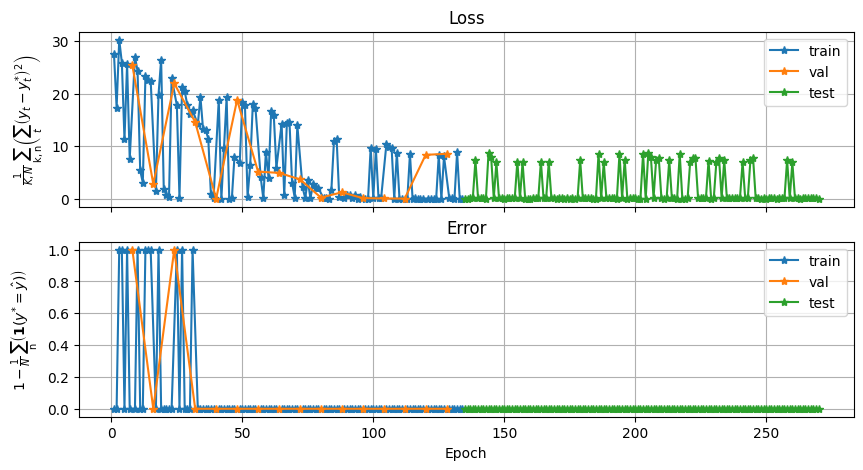

In [15]:
# Learning curves
train_curve = select_result_phase(net.results_dict, "train")
val_curve = select_result_phase(net.results_dict, "validation")
test_curve = select_result_phase(net.results_dict, "test") 

fig, ax = plt.subplots(2, 1, figsize=(10,5), sharex=True)
ax[0].plot(train_curve["it"], train_curve["loss"], "*-", label="train")
ax[0].plot(val_curve["it"], val_curve["loss"], "*-", label="val")
ax[0].plot(test_curve["it"], test_curve["loss"], "*-", label="test")
ax[0].grid()
ax[0].set_ylabel(r"$\frac{1}{K,N}\,\mathrm{\sum_{k,n}}\left(\sum_t\left(y_t - y_t^{*}\right)^2\right)$")
ax[0].legend(loc="upper right")
ax[0].set_title("Loss")


ax[1].plot(train_curve["it"], train_curve["error"], "*-", label="train")
ax[1].plot(val_curve["it"], val_curve["error"], "*-", label="val")
ax[1].plot(test_curve["it"], test_curve["error"], "*-", label="test")
ax[1].grid()
ax[1].set_title("Error")
ax[1].set_ylabel(r"$1 - \frac{1}{N}\,\mathrm{\sum_n}\left(\mathbf{1}(y^{*}=\hat{y})\right)$")
ax[1].legend(loc="upper right")
ax[1].set_xlabel("Epoch")

Confusion matrix train
[[62  0]
 [11 45]]
accuracy 90.6780
Confusion matrix train
[[9 0]
 [2 5]]
accuracy 87.5000
Confusion matrix test
[[64  0]
 [ 0 72]]
accuracy 100.0000


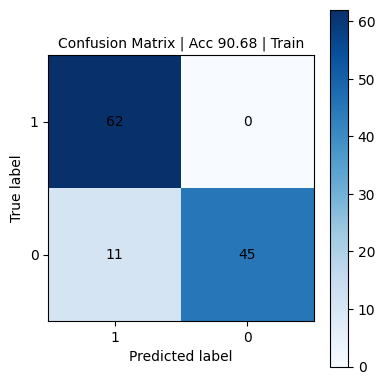

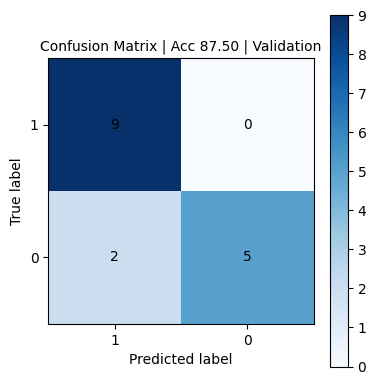

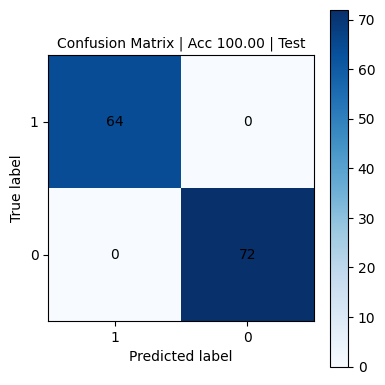

In [16]:
# Train confusion
y_pred = np.array(train_curve["y_pred"]).squeeze()
y_target = np.array(train_curve["y_target"]).squeeze()
conf_matrix = compute_confusion_matrix(y_pred, y_target)
print("Confusion matrix train")
print(conf_matrix)
acc = compute_accuracy_from_conf_matrix(conf_matrix)
print("accuracy", f"{acc:.4f}")
plot_confusion_matrix(conf_matrix, title="Train")

# Train confusion
y_pred = np.array(val_curve["y_pred"]).squeeze()
y_target = np.array(val_curve["y_target"]).squeeze()
conf_matrix = compute_confusion_matrix(y_pred, y_target)
print("Confusion matrix train")
print(conf_matrix)
acc = compute_accuracy_from_conf_matrix(conf_matrix)
print("accuracy", f"{acc:.4f}")
plot_confusion_matrix(conf_matrix, title="Validation")

# Test confusion
y_pred = np.array(test_curve["y_pred"]).squeeze()
y_target = np.array(test_curve["y_target"]).squeeze()
conf_matrix = compute_confusion_matrix(y_pred, y_target)
print("Confusion matrix test")
print(conf_matrix)
acc = compute_accuracy_from_conf_matrix(conf_matrix)
print("accuracy", f"{acc:.4f}")
plot_confusion_matrix(conf_matrix, title="Test")

/tmp/ipykernel_294754/3064180100.py:3: PerformanceWarning:indexing past lexsort depth may impact performance.


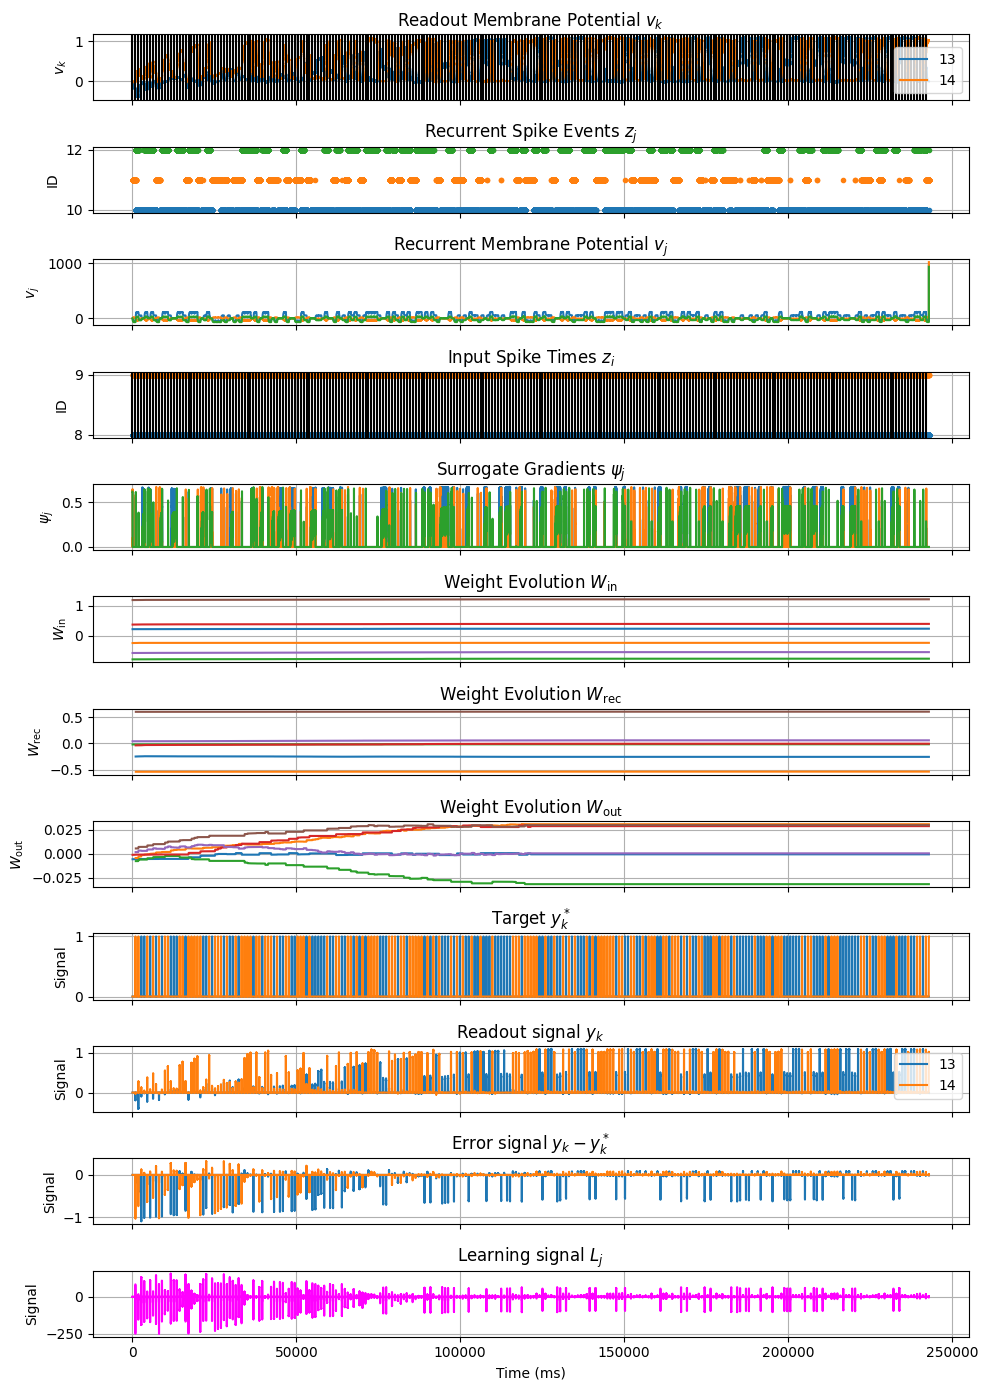

In [17]:
rows = 12
fig, axs = plt.subplots(rows, 1, figsize=(10, 14), sharex=True)

# Readout Membrane Potential
for i, sender in enumerate(np.unique(df_out.index)):
    mm_out_sender = df_out.loc[sender]
    axs[0].plot(mm_out_sender["times"], mm_out_sender["V_m"], color=f"C{i}", label=sender)
for epoch in range(epochs):
    axs[0].axvline(x=epoch * iteration_steps * params_setup["resolution"], color="k")
axs[0].set_ylabel(r"$v_k$")
axs[0].set_title(r"Readout Membrane Potential $v_k$")
axs[0].legend()
axs[0].grid()


# Plot 1: Recurrent spikes
for sender in np.unique(df_sr_rec.index):
    spk_times = df_sr_rec.loc[sender]
    axs[1].plot(spk_times, np.ones_like(spk_times) * sender, ".")
axs[1].set_ylabel("ID")
axs[1].set_title(r"Recurrent Spike Events $z_j$")
axs[1].grid()

# Plot 2: Recurrent Membrane Potential
for i, sender in enumerate(np.unique(df_mm_rec.index)):
    mm_rec_sender = df_mm_rec.loc[sender]
    axs[2].plot(mm_rec_sender["times"], mm_rec_sender["V_m"], color=f"C{i}", label=sender)
axs[2].set_ylabel(r"$v_j$")
axs[2].set_title(r"Recurrent Membrane Potential $v_j$")
#axs[2].legend(loc="upper right")
axs[2].grid()

# 6. Input spike times
for sender in np.unique(df_in.index):
    spk_times = df_in.loc[sender]
    axs[3].plot(spk_times, np.ones_like(spk_times) * sender, ".")
for epoch in range(epochs):
    axs[3].axvline(x=group_size * epoch * iteration_steps * params_setup["resolution"], color="k")
axs[3].set_ylabel("ID")
axs[3].set_title(r"Input Spike Times $z_i$")
axs[3].grid()

# Surrogate gradients
for i, sender in enumerate(np.unique(df_mm_rec.index)):
    mm_rec_sender = df_mm_rec.loc[sender]
    axs[4].plot(mm_rec_sender["times"], mm_rec_sender["surrogate_gradient"], color=f"C{i}")
axs[4].set_ylabel(r"$\psi_j$")
axs[4].set_title(r"Surrogate Gradients $\psi_j$")
axs[4].grid()

# 8. Weight evolution
plot_weight_time_course(df_in_rec, axs[5], label="in_rec")
axs[5].set_ylabel(r"$W_\text{in}$")
axs[5].set_title(r"Weight Evolution $W_\text{in}$")
axs[5].grid()
plot_weight_time_course(df_rec_rec, axs[6], label="rec_rec")
axs[6].set_ylabel(r"$W_\text{rec}$")
axs[6].set_title(r"Weight Evolution $W_\text{rec}$")
axs[6].grid()
plot_weight_time_course(df_rec_out, axs[7], label="rec_out")
axs[7].set_ylabel(r"$W_\text{out}$")
axs[7].set_title(r"Weight Evolution $W_\text{out}$")
axs[7].grid()
#axs[7].legend(loc="upper right")

# 7. Target signal
for i, sender in enumerate(np.unique(df_out.index)):
    mm_out_sender = df_out.loc[sender]
    axs[8].plot(mm_out_sender["times"], mm_out_sender["target_signal"])
#for epoch in range(epochs):
#    axs[8].axvline(x=group_size * epoch * iteration_steps * params_setup["resolution"], linestyle="--", color="k")
axs[8].set_ylabel("Signal")
axs[8].set_title(r"Target $y^*_k$")
#axs[8].legend(loc="upper right")
axs[8].grid()

# Readout signal
for i, sender in enumerate(np.unique(df_out.index)):
    mm_out_sender = df_out.loc[sender]
    axs[9].plot(mm_out_sender["times"], mm_out_sender["readout_signal"], label=sender)
#for epoch in range(epochs):
#    axs[9].axvline(x=group_size * epoch * iteration_steps * params_setup["resolution"], linestyle="--", color="k")
axs[9].set_ylabel("Signal")
axs[9].set_title(r"Readout signal $y_k$")
axs[9].legend(loc="upper right")
axs[9].grid()

# Error signal
for i, sender in enumerate(np.unique(df_out.index)):
    mm_out_sender = df_out.loc[sender]
    axs[10].plot(mm_out_sender["times"], mm_out_sender["error_signal"])
axs[10].set_ylabel("Signal")
axs[10].set_title(r"Error signal $y_k-y^*_k$")
#axs[10].legend(loc="upper right")
axs[10].grid()

for i, sender in enumerate(np.unique(df_mm_rec.index)):
    mm_rec_sender = df_mm_rec.loc[sender]
    axs[11].plot(mm_rec_sender["times"], mm_rec_sender["learning_signal"], color="magenta")
axs[11].set_ylabel("Signal")
axs[11].set_title(r"Learning signal $L_j$")
axs[11].grid()

axs[11].set_xlabel("Time (ms)")

plt.tight_layout()

In [18]:
plt.show()